# Analisis Sentimen Wondr by BNI 2 Algorithm (LSTM & GRU)

In [1]:
!pip install google-play-scraper Sastrawi tensorflow scikit-learn matplotlib pandas numpy nltk emoji wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 804.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk,re,time
import emoji
from google_play_scraper import reviews, Sort
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# Scraping 5000 review
APP_ID='id.bni.wondr'
TOTAL_REVIEWS=5000
BATCH_SIZE=200
all_reviews=[]
token=None
while len(all_reviews)<TOTAL_REVIEWS:
    batch,token=reviews(APP_ID,lang='id',country='id',sort=Sort.NEWEST,count=BATCH_SIZE,continuation_token=token)
    all_reviews.extend(batch)
    if token is None:
        break
    time.sleep(1)
df=pd.DataFrame(all_reviews[:TOTAL_REVIEWS])
df.to_csv('wondrbyBNI.csv',index=False,encoding='utf-8-sig')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1491b193-c97d-4fee-8ba2-231e8d28a891,Dedi Agus Syahputra,https://play-lh.googleusercontent.com/a-/ALV-U...,Bagus,5,0,1.5.1,2026-07-13 23:37:33,None,NaT,1.5.1
1,adef2b7d-f6f2-4a60-af38-68491eca9989,Nur Aisyah,https://play-lh.googleusercontent.com/a/ACg8oc...,sangat membantu bagi saya,5,0,1.5.1,2026-07-13 23:25:46,None,NaT,1.5.1
2,c051d406-6739-438f-89d0-0c5ecdb1ec6e,Pondoyo Yoyo,https://play-lh.googleusercontent.com/a/ACg8oc...,puas,5,0,1.5.1,2026-07-13 22:42:19,None,NaT,1.5.1
3,ba4a158c-572c-442c-9367-87fee013469b,Jal,https://play-lh.googleusercontent.com/a/ACg8oc...,baru kali ini saya top up dari seebank ke reke...,3,0,1.5.1,2026-07-13 22:38:11,"Halo Kak Jal, kami turut menyesal atas kendala...",2026-07-14 07:53:29,1.5.1
4,1a4ccdcd-8ef9-493b-9c45-97d11d2307b3,Yuli Anto,https://play-lh.googleusercontent.com/a-/ALV-U...,yess oke,5,0,1.5.1,2026-07-13 22:38:07,None,NaT,1.5.1


## Lanjutkan dengan EDA, preprocessing, pelabelan, LSTM, dan evaluasi.

TAHAP 2 : EXPLORATORY DATA ANALYSIS

Ukuran Dataset
------------------------------------------------------------
Jumlah Baris : 5000
Jumlah Kolom : 11

Informasi Dataset
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              5000 non-null   object
 1   userName              5000 non-null   object
 2   userImage             5000 non-null   object
 3   content               5000 non-null   object
 4   score                 5000 non-null   int64 
 5   thumbsUpCount         5000 non-null   int64 
 6   reviewCreatedVersion  4538 non-null   object
 7   at                    5000 non-null   object
 8   replyContent          1487 non-null   object
 9   repliedAt             1487 non-null   object
 10  appVersion            4538 non-null   object
dtypes: int6

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1491b193-c97d-4fee-8ba2-231e8d28a891,Dedi Agus Syahputra,https://play-lh.googleusercontent.com/a-/ALV-U...,Bagus,5,0,1.5.1,2026-07-13 23:37:33,NaN,NaN,1.5.1
1,adef2b7d-f6f2-4a60-af38-68491eca9989,Nur Aisyah,https://play-lh.googleusercontent.com/a/ACg8oc...,sangat membantu bagi saya,5,0,1.5.1,2026-07-13 23:25:46,NaN,NaN,1.5.1
2,c051d406-6739-438f-89d0-0c5ecdb1ec6e,Pondoyo Yoyo,https://play-lh.googleusercontent.com/a/ACg8oc...,puas,5,0,1.5.1,2026-07-13 22:42:19,NaN,NaN,1.5.1
3,ba4a158c-572c-442c-9367-87fee013469b,Jal,https://play-lh.googleusercontent.com/a/ACg8oc...,baru kali ini saya top up dari seebank ke reke...,3,0,1.5.1,2026-07-13 22:38:11,"Halo Kak Jal, kami turut menyesal atas kendala...",2026-07-14 07:53:29,1.5.1
4,1a4ccdcd-8ef9-493b-9c45-97d11d2307b3,Yuli Anto,https://play-lh.googleusercontent.com/a-/ALV-U...,yess oke,5,0,1.5.1,2026-07-13 22:38:07,NaN,NaN,1.5.1



5 Data Terakhir


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
4995,608b8af9-6d15-4c15-85b5-aff91958e9ac,Agus Susanto,https://play-lh.googleusercontent.com/a/ACg8oc...,baik sekali,5,0,NaN,2026-06-04 03:42:35,NaN,NaN,NaN
4996,f2d1a30a-39cc-4889-9d6a-fe355ccfe395,Rasyid Jalling,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat mudah dan baik sekaliii,5,0,1.5.0,2026-06-04 03:42:26,NaN,NaN,1.5.0
4997,b3da6158-241b-4ce8-974a-46f6f6aa7ffe,Hadi Jaya selalu 99,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap,5,0,1.5.0,2026-06-04 03:38:27,NaN,NaN,1.5.0
4998,af6df427-c2ac-4588-baf7-be953e7204ef,Nova Yanti,https://play-lh.googleusercontent.com/a/ACg8oc...,mantul,5,0,1.5.0,2026-06-04 03:37:17,NaN,NaN,1.5.0
4999,e571ccea-536c-4654-9547-9054f77636f3,Andali Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Good,5,0,1.5.0,2026-06-04 03:33:05,NaN,NaN,1.5.0



Missing Value


,Jumlah Missing
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,462
at,0
replyContent,3513
repliedAt,3513



Data Duplikat
Duplikat Seluruh Baris : 0
Duplikat Isi Review    : 1971


,Jumlah Review
score,
1,786
2,166
3,196
4,326
5,3526


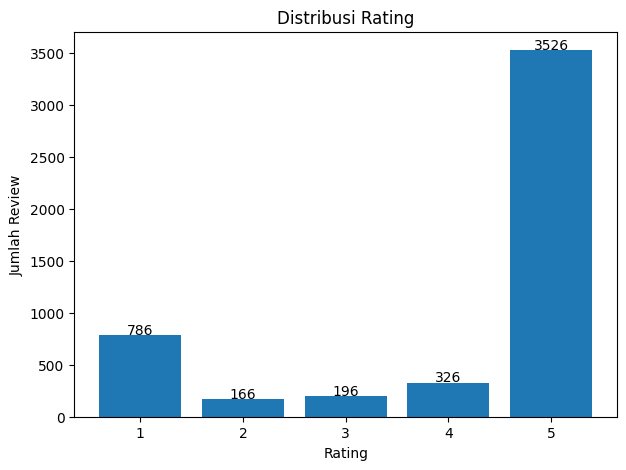

,jumlah_kata
count,5000.000000
mean,7.104000
std,11.328126
min,1.000000
25%,1.000000
50%,2.000000
75%,7.000000
max,92.000000


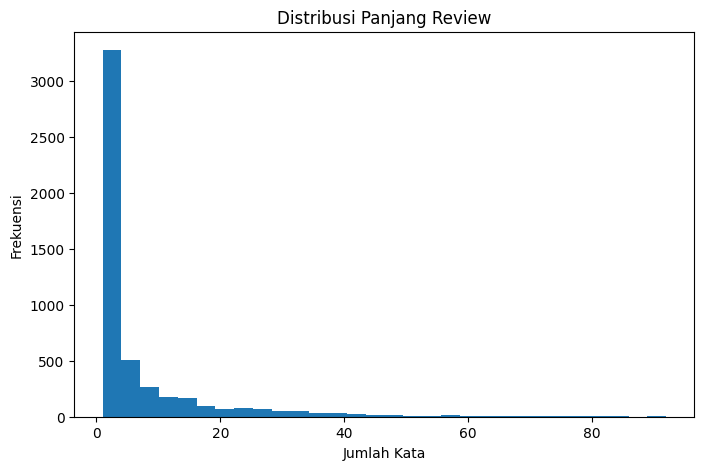

,Jumlah
content,
mantap,264
bagus,240
ok,192
baik,151
good,128
sangat bagus,103
sangat membantu,99
sangat baik,79
oke,46



EDA selesai.


In [4]:
print("="*60)
print("TAHAP 2 : EXPLORATORY DATA ANALYSIS")
print("="*60)

# Load dataset hasil scraping
df = pd.read_csv("wondrbyBNI.csv")

print("\nUkuran Dataset")
print("-"*60)
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

print("\nInformasi Dataset")
print("-"*60)
df.info()

print("\n5 Data Pertama")
display(df.head())

print("\n5 Data Terakhir")
display(df.tail())

# ==================================================
# Missing Value
# ==================================================

print("\nMissing Value")
missing = df.isnull().sum()

display(missing.to_frame("Jumlah Missing"))

# ==================================================
# Data Duplikat
# ==================================================

print("\nData Duplikat")

duplikat_baris = df.duplicated().sum()
duplikat_review = df["content"].duplicated().sum()

print("Duplikat Seluruh Baris :", duplikat_baris)
print("Duplikat Isi Review    :", duplikat_review)

# ==================================================
# Hapus Missing
# ==================================================

df.dropna(subset=["content"], inplace=True)
df.reset_index(drop=True, inplace=True)

# ==================================================
# Distribusi Rating
# ==================================================

rating = df["score"].value_counts().sort_index()

display(rating.to_frame("Jumlah Review"))

plt.figure(figsize=(7,5))
plt.bar(rating.index.astype(str), rating.values)

plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")

for i,v in enumerate(rating.values):
    plt.text(i,v+10,str(v),ha="center")

plt.show()

# ==================================================
# Statistik Panjang Review
# ==================================================

df["jumlah_kata"] = df["content"].astype(str).apply(
    lambda x: len(x.split())
)

display(df["jumlah_kata"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["jumlah_kata"],bins=30)

plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")

plt.show()

# ==================================================
# Review yang Paling Sering Muncul
# ==================================================

display(
    df["content"]
    .value_counts()
    .head(10)
    .to_frame("Jumlah")
)

df.to_csv(
    "wondrbyBNI_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nEDA selesai.")

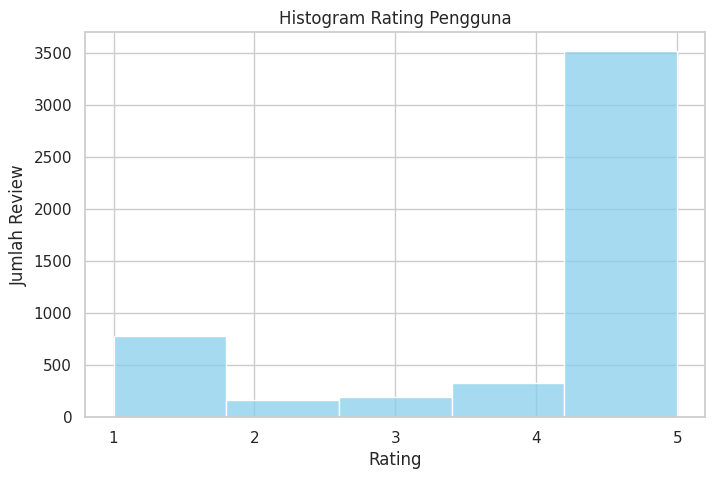

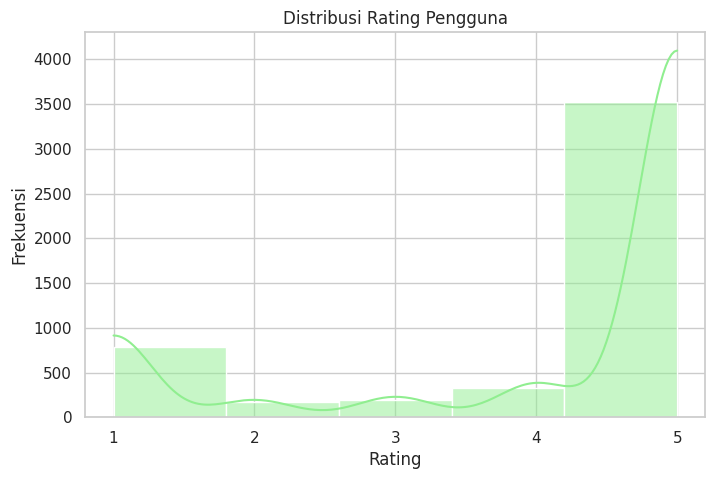

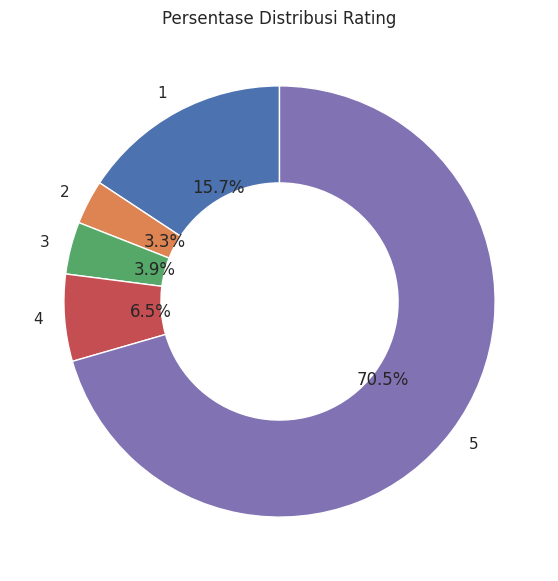

In [5]:
# ==========================================================
# VISUALISASI DATA
# Histogram, Distribusi, dan Diagram Donat
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------
# 1. Histogram Rating
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['score'], bins=5, kde=False, color='skyblue')
plt.title("Histogram Rating Pengguna")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.xticks([1,2,3,4,5])
plt.show()


# -----------------------------
# 2. Grafik Distribusi Rating
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['score'], kde=True, bins=5, color='lightgreen')
plt.title("Distribusi Rating Pengguna")
plt.xlabel("Rating")
plt.ylabel("Frekuensi")
plt.xticks([1,2,3,4,5])
plt.show()


# -----------------------------
# 3. Diagram Donat (Pie Chart)
# -----------------------------
rating_counts = df['score'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.45}   # Membuat pie menjadi donat
)

plt.title("Persentase Distribusi Rating")
plt.show()

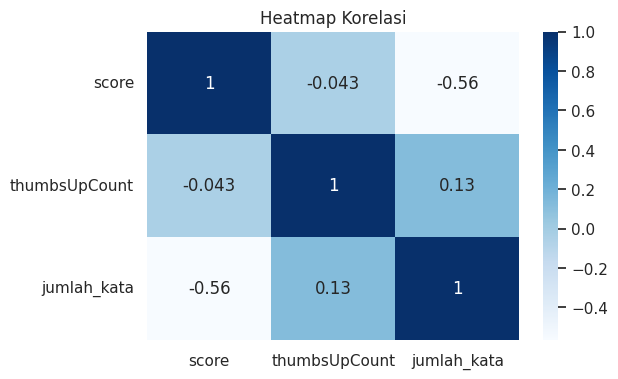

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric.corr(), annot=True, cmap='Blues')
plt.title("Heatmap Korelasi")
plt.show()

TAHAP 3 : TEXT PREPROCESSING

Hasil Preprocessing


,content,stemming
0,Bagus,bagus
1,sangat membantu bagi saya,bantu
2,puas,puas
3,baru kali ini saya top up dari seebank ke reke...,kali top up seebank rekening bni jam set mlm s...
4,yess oke,yess oke



Statistik Panjang Review


,jumlah_kata
count,5000.000000
mean,4.273000
std,6.603665
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,59.000000


,Kata,Frekuensi
0,bagus,703
1,aplikasi,570
2,bni,445
3,transaksi,437
4,mudah,428
5,mantap,405
6,bantu,369
7,masuk,301
8,saldo,272
9,ok,271


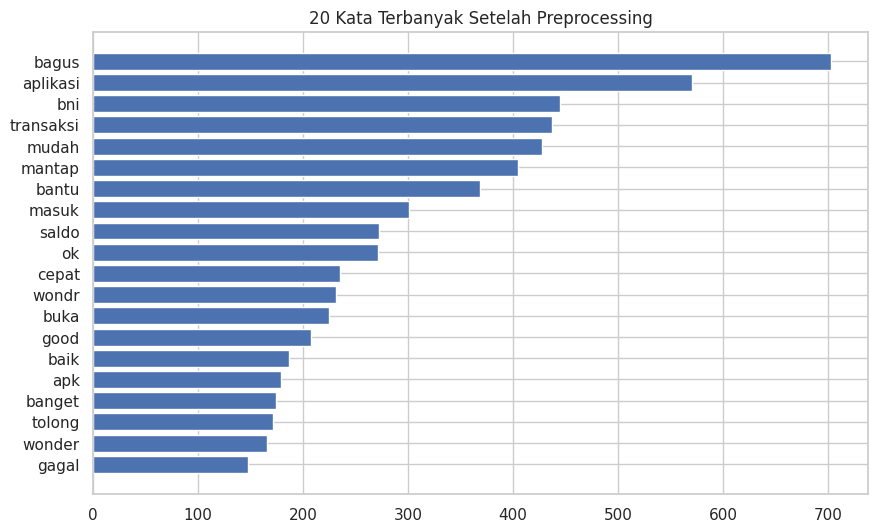

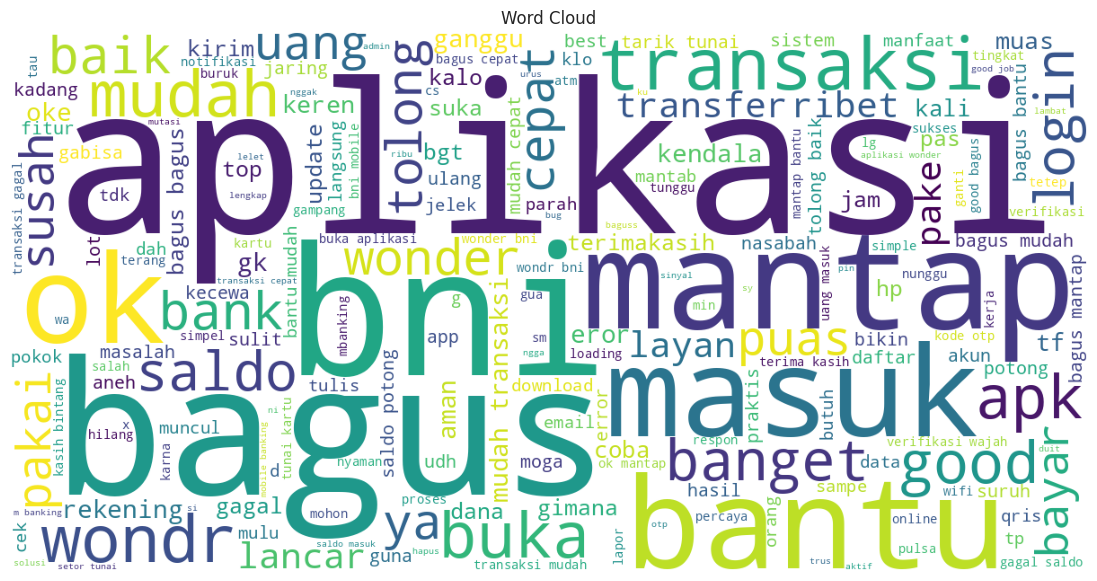


Preprocessing selesai.
Dataset disimpan sebagai wondrbyBNI_preprocessing.csv


In [9]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

df = pd.read_csv('wondrbyBNI_clean.csv')

# ==========================================================
# TAHAP 3 : TEXT PREPROCESSING
# ==========================================================

print("="*60)
print("TAHAP 3 : TEXT PREPROCESSING")
print("="*60)

# ==========================================================
# STEMMER DAN STOPWORDS
# ==========================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words("indonesian"))

custom_stopwords = {
    "yg","nya","aja","ga","gak","nih",
    "dong","kok","sih","udah","br"
}

stop_words.update(custom_stopwords)

# ==========================================================
# CASE FOLDING
# ==========================================================

df["case_folding"] = df["content"].astype(str).str.lower()

# ==========================================================
# CLEANING
# ==========================================================

def cleaning(text):

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    text = emoji.replace_emoji(text, replace="")

    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["cleaning"] = df["case_folding"].apply(cleaning)

# ==========================================================
# TOKENIZING
# ==========================================================

df["tokenizing"] = df["cleaning"].apply(word_tokenize)

# ==========================================================
# STOPWORD REMOVAL
# ==========================================================

def remove_stopword(tokens):
    return [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

df["stopword"] = df["tokenizing"].apply(remove_stopword)

# ==========================================================
# STEMMING
# ==========================================================

def stemming(tokens):
    return " ".join(
        stemmer.stem(kata)
        for kata in tokens
    )

df["stemming"] = df["stopword"].apply(stemming)

print("\nHasil Preprocessing")

display(
    df[
        [
            "content",
            "stemming"
        ]
    ].head()
)

# ==========================================================
# PANJANG REVIEW SETELAH PREPROCESSING
# ==========================================================

df["jumlah_kata"] = df["stemming"].apply(
    lambda x: len(x.split())
)

print("\nStatistik Panjang Review")

display(df["jumlah_kata"].describe())

# ==========================================================
# 20 KATA TERBANYAK
# ==========================================================

all_words = " ".join(df["stemming"])

word_freq = Counter(all_words.split())

top20 = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Kata","Frekuensi"]
)

display(top20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Kata"],
    top20["Frekuensi"]
)

plt.gca().invert_yaxis()

plt.title("20 Kata Terbanyak Setelah Preprocessing")

plt.show()

# ==========================================================
# WORD CLOUD
# ==========================================================

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

# ==========================================================
# SIMPAN HASIL
# ==========================================================

df.to_csv(
    "wondrbyBNI_preprocessing.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPreprocessing selesai.")
print("Dataset disimpan sebagai wondrbyBNI_preprocessing.csv")

In [46]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Ensure NLTK data is downloaded if not already
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

df = pd.read_csv('wondrbyBNI_clean.csv')

print("==========================================================")
print("TAHAP 3 : TEXT PREPROCESSING - HASIL PISAH")
print("==========================================================")

# ==========================================================
# 1. Data Cleaning (Setup Stemmer dan Stopwords)
# ==========================================================
print("\n--- 1. Data Cleaning (Setup Stemmer dan Stopwords) ---")
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words("indonesian"))

custom_stopwords = {
    "yg","nya","aja","ga","gak","nih",
    "dong","kok","sih","udah","br"
}

stop_words.update(custom_stopwords)
print("Stemmer dan Stopwords berhasil diinisialisasi.")
print("Dataframe awal:")
display(df[['content']].head())

# ==========================================================
# 2. Case Folding
# ==========================================================
print("\n--- 2. Case Folding ---")
df["case_folding"] = df["content"].astype(str).str.lower()
print("Hasil Case Folding:")
display(df[['content', 'case_folding']].head())

# ==========================================================
# 3. Cleaning Text
# ==========================================================
print("\n--- 3. Cleaning Text ---")
def cleaning(text):

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    text = emoji.replace_emoji(text, replace="")

    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["cleaning"] = df["case_folding"].apply(cleaning)
print("Hasil Cleaning Text:")
display(df[['case_folding', 'cleaning']].head())

# ==========================================================
# 4. Tokenizing
# ==========================================================
print("\n--- 4. Tokenizing ---")
df["tokenizing"] = df["cleaning"].apply(word_tokenize)
print("Hasil Tokenizing:")
display(df[['cleaning', 'tokenizing']].head())

# ==========================================================
# 5. Stopword Removal
# ==========================================================
print("\n--- 5. Stopword Removal ---")
def remove_stopword(tokens):
    return [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

df["stopword"] = df["tokenizing"].apply(remove_stopword)
print("Hasil Stopword Removal:")
display(df[['tokenizing', 'stopword']].head())

# ==========================================================
# 6. Stemming
# ==========================================================
print("\n--- 6. Stemming ---")
def stemming(tokens):
    return " ".join(
        stemmer.stem(kata)
        for kata in tokens
    )

df["stemming"] = df["stopword"].apply(stemming)
print("Hasil Stemming:")
display(df[['stopword', 'stemming']].head())

print("\nSemua tahapan preprocessing telah dipisahkan dan hasilnya ditampilkan.")

TAHAP 3 : TEXT PREPROCESSING - HASIL PISAH

--- 1. Data Cleaning (Setup Stemmer dan Stopwords) ---
Stemmer dan Stopwords berhasil diinisialisasi.
Dataframe awal:


,content
0,Bagus
1,sangat membantu bagi saya
2,puas
3,baru kali ini saya top up dari seebank ke reke...
4,yess oke



--- 2. Case Folding ---
Hasil Case Folding:


,content,case_folding
0,Bagus,bagus
1,sangat membantu bagi saya,sangat membantu bagi saya
2,puas,puas
3,baru kali ini saya top up dari seebank ke reke...,baru kali ini saya top up dari seebank ke reke...
4,yess oke,yess oke



--- 3. Cleaning Text ---
Hasil Cleaning Text:


...


--- 5. Stopword Removal ---
Hasil Stopword Removal:


,tokenizing,stopword
0,[bagus],[bagus]
1,"[sangat, membantu, bagi, saya]",[membantu]
2,[puas],[puas]
3,"[baru, kali, ini, saya, top, up, dari, seebank...","[kali, top, up, seebank, rekening, bni, jam, s..."
4,"[yess, oke]","[yess, oke]"



--- 6. Stemming ---
Hasil Stemming:


,stopword,stemming
0,[bagus],bagus
1,[membantu],bantu
2,[puas],puas
3,"[kali, top, up, seebank, rekening, bni, jam, s...",kali top up seebank rekening bni jam set mlm s...
4,"[yess, oke]",yess oke



Semua tahapan preprocessing telah dipisahkan dan hasilnya ditampilkan.


TAHAP 4 : PELABELAN SENTIMEN

Distribusi Sentimen


,count
sentimen,
Netral,2401
Positif,2032
Negatif,567


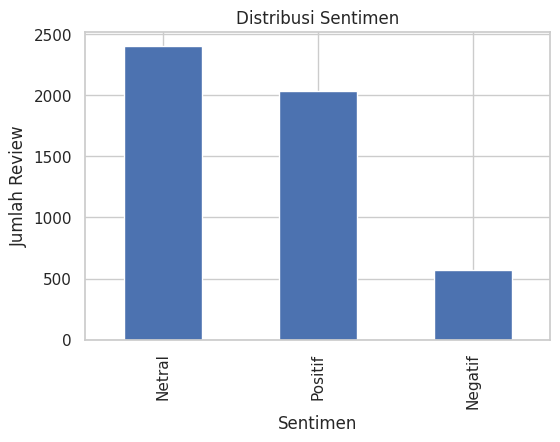


Pelabelan selesai.


In [10]:
# ==========================================================
# TAHAP 4 : PELABELAN SENTIMEN
# ==========================================================

print("="*60)
print("TAHAP 4 : PELABELAN SENTIMEN")
print("="*60)

kamus_positif = {
    "bagus","baik","mantap","keren","cepat","mudah",
    "praktis","lancar","aman","nyaman","membantu",
    "puas","memuaskan","hebat","terbaik","stabil",
    "responsif","lengkap","oke","top"
}

kamus_negatif = {
    "jelek","buruk","error","eror","bug","crash",
    "gagal","lemot","lambat","ganggu","login",
    "otp","blank","freeze","kecewa","parah",
    "susah","ribet","maintenance","hilang"
}


def label_sentimen(text):

    positif = 0
    negatif = 0

    for kata in text.split():

        if kata in kamus_positif:
            positif += 1

        if kata in kamus_negatif:
            negatif += 1

    if positif > negatif:
        return "Positif"

    elif negatif > positif:
        return "Negatif"

    else:
        return "Netral"


df["sentimen"] = df["stemming"].apply(label_sentimen)

print("\nDistribusi Sentimen")

display(df["sentimen"].value_counts())

plt.figure(figsize=(6,4))

df["sentimen"].value_counts().plot(
    kind="bar"
)

plt.title("Distribusi Sentimen")

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Review")

plt.show()

df.to_csv(
    "wondrbyBNI_sentimen.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPelabelan selesai.")

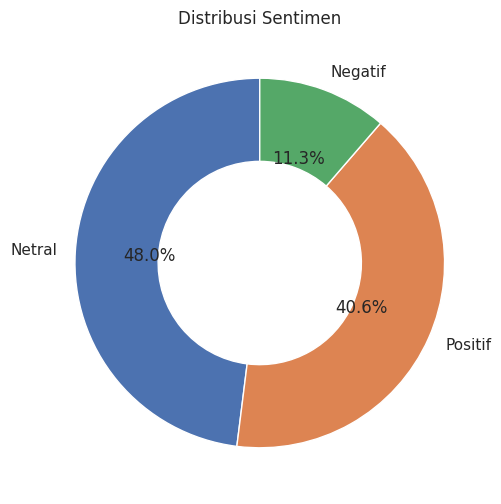

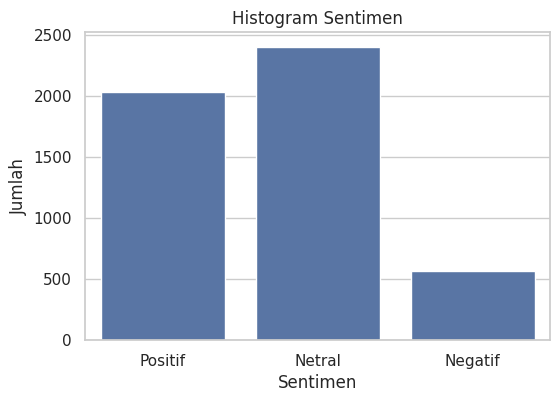

In [11]:
# Distribusi Sentimen
sentimen_count = df['sentimen'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sentimen_count,
    labels=sentimen_count.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.45}
)
plt.title("Distribusi Sentimen")
plt.show()


# Histogram Sentimen
plt.figure(figsize=(6,4))
sns.countplot(x='sentimen', data=df)
plt.title("Histogram Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

Data LSTM

In [15]:
# ==========================================================
# TAHAP 5 : PERSIAPAN DATA LSTM
# ==========================================================

print("="*60)
print("TAHAP 5 : PERSIAPAN DATA LSTM")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import pandas as pd # Import pandas

# Load the processed dataframe
df = pd.read_csv('wondrbyBNI_sentimen.csv')

# ==========================================================
# FITUR DAN LABEL
# ==========================================================

X = df["stemming"].fillna("").astype(str)

y = df["sentimen"]

# ==========================================================
# ENCODING LABEL
# ==========================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\nMapping Label")

for kelas, angka in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    print(f"{kelas} --> {angka}")

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nJumlah Data")

print("Data Latih :", len(X_train))
print("Data Uji   :", len(X_test))

# ==========================================================
# TOKENIZER
# ==========================================================

VOCAB_SIZE = 10000

MAX_LENGTH = 100

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)

X_test = tokenizer.texts_to_sequences(X_test)

# ==========================================================
# PADDING
# ==========================================================

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# ==========================================================
# ONE HOT ENCODING
# ==========================================================

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

print("\nShape Data")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nPersiapan data selesai.")

TAHAP 5 : PERSIAPAN DATA LSTM

Mapping Label
Negatif --> 0
Netral --> 1
Positif --> 2

Jumlah Data
Data Latih : 4000
Data Uji   : 1000

Shape Data
X_train : (4000, 100)
X_test  : (1000, 100)
y_train : (4000, 3)
y_test  : (1000, 3)

Persiapan data selesai.


Pemodelan Algoritma LSTM

In [16]:
import tensorflow as tf

tf.keras.backend.clear_session() # Clear any old TensorFlow session state

# ==========================================================
# TAHAP 6 : PEMBANGUNAN MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 6 : PEMBANGUNAN MODEL LSTM")
print("="*60)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Define VOCAB_SIZE and MAX_LENGTH from the data preparation step
VOCAB_SIZE = 10000
MAX_LENGTH = 100

# ==========================================================
# CALLBACK
# ==========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "model_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# ==========================================================
# MODEL
# ==========================================================

model = Sequential()

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
        # Removed deprecated input_length argument
    )
)

model.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        3,
        activation="softmax"
    )
)

# Explicitly build the model before summary and training
model.build(input_shape=(None, MAX_LENGTH))

# ==========================================================
# COMPILE
# ==========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

TAHAP 6 : PEMBANGUNAN MODEL LSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,715,971 (6.55 MB)

 Trainable params: 1,715,971 (6.55 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ==========================================================
# TAHAP 7 : TRAINING MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 7 : TRAINING MODEL LSTM")
print("="*60)

import time

start_time_lstm = time.time()

history = model.fit(
    X_train,
    y_train, # Use y_train directly as it's already one-hot encoded
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test), # Use y_test directly as it's already one-hot encoded
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

training_time_lstm = time.time() - start_time_lstm

print(f"\nTraining selesai dalam {training_time_lstm:.2f} detik")

TAHAP 7 : TRAINING MODEL LSTM
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 552ms/step - accuracy: 0.6890 - loss: 0.6372 - val_accuracy: 0.8940 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 553ms/step - accuracy: 0.9538 - loss: 0.1433 - val_accuracy: 0.9450 - val_loss: 0.1656 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 540ms/step - accuracy: 0.9747 - loss: 0.0798 - val_accuracy: 0.9560 - val_loss: 0.1264 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 542ms/step - accuracy: 0.9870 - loss: 0.0429 - val_accuracy: 0.9550 - val_loss: 0.1921 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9952 - loss: 0.0199
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 545ms/step - accuracy: 0.9945 - loss: 0.0219 - val_accuracy: 0.9590 - val_loss: 0.1686 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 82

In [18]:
# ==========================================================
# TAHAP 8 : EVALUASI MODEL LSTM
# ==========================================================

print("="*60)
print("TAHAP 8 : EVALUASI MODEL LSTM")
print("="*60)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
# from tensorflow.keras.utils import to_categorical # Removed, as y_test is already one-hot encoded

# y_test is already one-hot encoded from the data preparation step
# y_test_one_hot = to_categorical(y_test, num_classes=len(encoder.classes_))

# Evaluasi model
loss, acc = model.evaluate(
    X_test,
    y_test, # Use y_test directly as it's already one-hot encoded
    verbose=0
)

print(f"Loss     : {loss:.4f}")
print(f"Akurasi  : {acc*100:.2f}%")

# Prediksi
y_pred = model.predict(X_test, verbose=0)

y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1) # Use the one-hot encoded y_test for argmax

# Hitung metrik
accuracy_lstm = accuracy_score(y_true, y_pred_class)

precision_lstm = precision_score(
    y_true,
    y_pred_class,
    average="weighted"
)

recall_lstm = recall_score(
    y_true,
    y_pred_class,
    average="weighted"
)

f1_lstm = f1_score(
    y_true,
    y_pred_class,
    average="weighted"
)

print("\nClassification Report")
print(classification_report(
    y_true,
    y_pred_class,
    target_names=encoder.classes_
))

TAHAP 8 : EVALUASI MODEL LSTM
Loss     : 0.1264
Akurasi  : 95.60%

Classification Report
              precision    recall  f1-score   support

     Negatif       0.90      0.92      0.91       113
      Netral       0.95      0.95      0.95       480
     Positif       0.98      0.97      0.97       407

    accuracy                           0.96      1000
   macro avg       0.94      0.95      0.94      1000
weighted avg       0.96      0.96      0.96      1000



In [34]:
print("============================================================")
print("METRIK EVALUASI LSTM")
print("============================================================")

print(f"Accuracy  LSTM: {accuracy_lstm*100:.2f}%")
print(f"Precision LSTM: {precision_lstm*100:.2f}%")
print(f"Recall    LSTM: {recall_lstm*100:.2f}%")
print(f"F1-Score  LSTM: {f1_lstm*100:.2f}%")

METRIK EVALUASI LSTM
Accuracy  LSTM: 95.60%
Precision LSTM: 95.62%
Recall    LSTM: 95.60%
F1-Score  LSTM: 95.61%


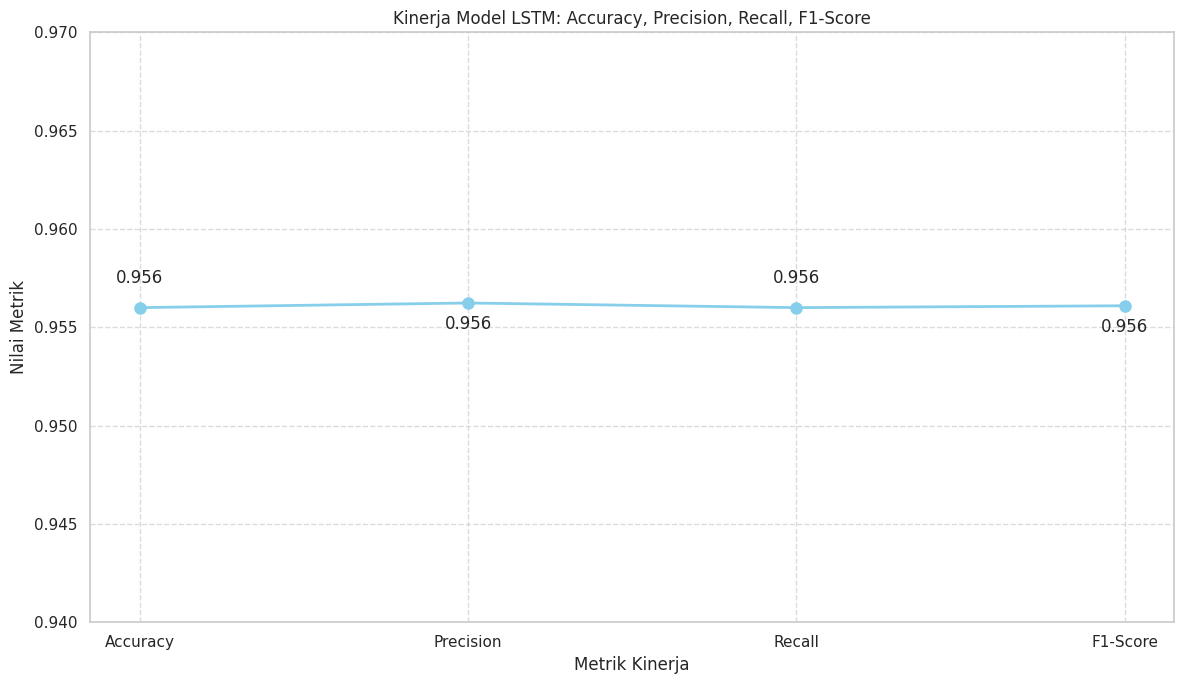

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data for LSTM model
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values_lstm = [
    accuracy_lstm,
    precision_lstm,
    recall_lstm,
    f1_lstm
]

plt.figure(figsize=(12, 7)) # Increase figure size for better readability

# Plot the line chart
plt.plot(metric_names, metric_values_lstm, marker='o', linestyle='-', color='skyblue', linewidth=2, markersize=8)

# Add value labels for each point with slight vertical offsets to prevent overlap
offsets = [15, -15, 15, -15] # Alternate offsets for better readability
for i, txt in enumerate(metric_values_lstm):
    plt.annotate(f'{txt:.3f}', (metric_names[i], metric_values_lstm[i]),
                 textcoords="offset points", xytext=(0, offsets[i]), # Apply alternating offset
                 ha='center', va='center' if offsets[i] < 0 else 'bottom') # Adjust vertical alignment

plt.ylim(0.94, 0.97) # Adjust y-axis limits to zoom in but leave more space for labels
plt.ylabel('Nilai Metrik')
plt.xlabel('Metrik Kinerja')
plt.title('Kinerja Model LSTM: Accuracy, Precision, Recall, F1-Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

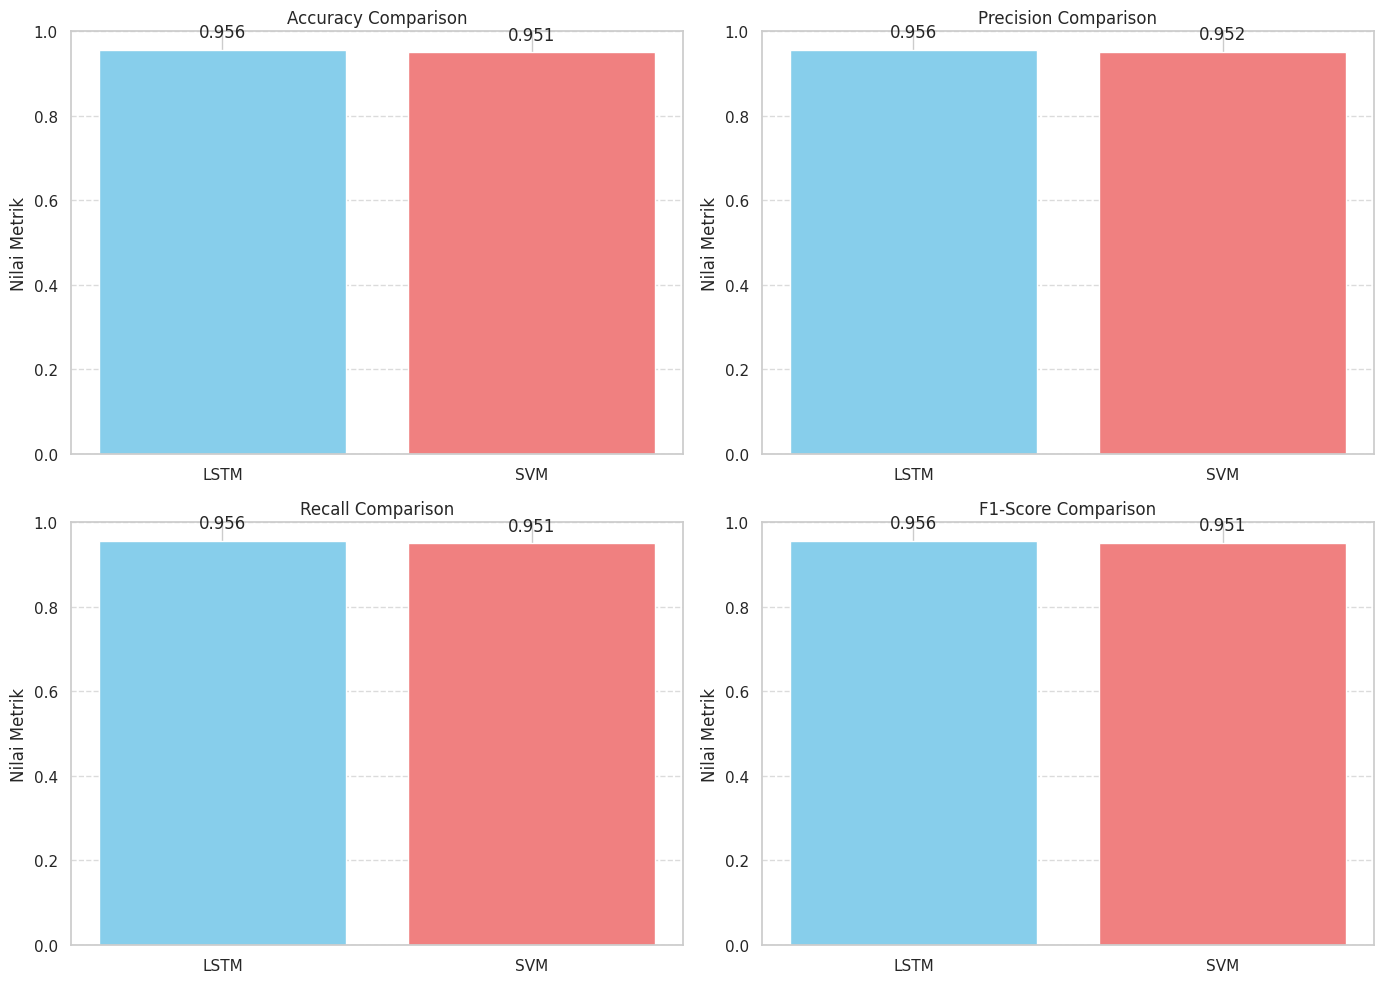

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data (already available in kernel state)
metrics = [
    ("Accuracy", accuracy_lstm, accuracy_svm),
    ("Precision", precision_lstm, precision_svm),
    ("Recall", recall_lstm, recall_svm),
    ("F1-Score", f1_lstm, f1_svm)
]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, (metric_name, lstm_value, svm_value) in enumerate(metrics):
    ax = axes[i]

    labels = ['LSTM', 'SVM']
    values = [lstm_value, svm_value]
    colors = ['skyblue', 'lightcoral']

    ax.bar(labels, values, color=colors)
    ax.set_ylim(0, 1) # Metrics are typically between 0 and 1
    ax.set_ylabel('Nilai Metrik')
    ax.set_title(f'{metric_name} Comparison')

    # Add value labels on top of each bar for readability
    for j, value in enumerate(values):
        ax.text(j, value + 0.02, f'{value:.3f}', ha='center', va='bottom')

    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

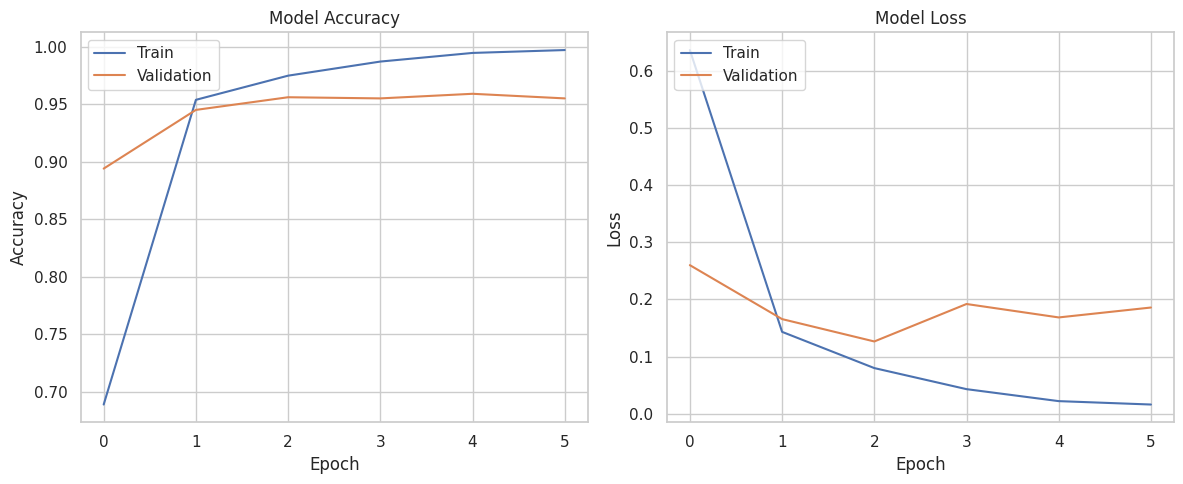

In [36]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

CONFUSION MATRIX LSTM


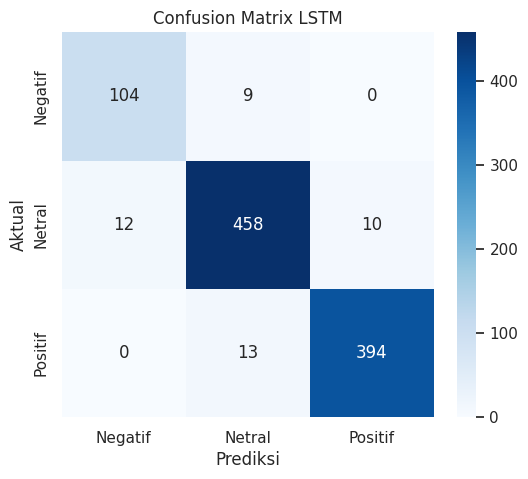

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("============================================================")
print("CONFUSION MATRIX LSTM")
print("============================================================")

cm_lstm = confusion_matrix(
    y_true,
    y_pred_class
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix LSTM")

plt.show()

In [19]:
# ==========================================================
# TAHAP 5 : PERSIAPAN DATA SVM
# ==========================================================

print("="*60)
print("TAHAP 5 : PERSIAPAN DATA SVM")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================================
# FITUR DAN LABEL
# ==========================================================

X = df["stemming"].fillna("").astype(str)
y = df["sentimen"]

# ==========================================================
# ENCODING LABEL
# ==========================================================

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nMapping Label")

for kelas, angka in zip(encoder.classes_,
                         encoder.transform(encoder.classes_)):
    print(f"{kelas} --> {angka}")

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nJumlah Data")
print("Data Latih :", len(X_train))
print("Data Uji   :", len(X_test))

# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

print("\nShape Data")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

TAHAP 5 : PERSIAPAN DATA SVM

Mapping Label
Negatif --> 0
Netral --> 1
Positif --> 2

Jumlah Data
Data Latih : 4000
Data Uji   : 1000

Shape Data
X_train : (4000, 10000)
X_test  : (1000, 10000)


In [20]:
# ==========================================================
# TAHAP 6 : PEMBANGUNAN MODEL SVM
# ==========================================================

print("="*60)
print("TAHAP 6 : PEMBANGUNAN MODEL SVM")
print("="*60)

from sklearn.svm import SVC

model_svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

print("Model SVM berhasil dibuat.")

TAHAP 6 : PEMBANGUNAN MODEL SVM
Model SVM berhasil dibuat.


In [21]:
# ==========================================================
# TAHAP 7 : TRAINING MODEL
# ==========================================================

print("="*60)
print("TAHAP 7 : TRAINING MODEL")
print("="*60)

import time

start = time.time()

model_svm.fit(X_train, y_train)

training_time_svm = time.time() - start

print(f"Training selesai dalam {training_time_svm:.2f} detik")

TAHAP 7 : TRAINING MODEL
Training selesai dalam 0.70 detik


In [22]:
# ==========================================================
# TAHAP 8 : EVALUASI MODEL
# ==========================================================

print("="*60)
print("TAHAP 8 : EVALUASI MODEL")
print("="*60)

from sklearn.metrics import accuracy_score

y_pred = model_svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred)

print(f"Akurasi : {accuracy_svm*100:.2f}%")

TAHAP 8 : EVALUASI MODEL
Akurasi : 95.10%


In [23]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

     Negatif       0.85      0.88      0.86       113
      Netral       0.95      0.95      0.95       480
     Positif       0.99      0.97      0.98       407

    accuracy                           0.95      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.95      0.95      0.95      1000



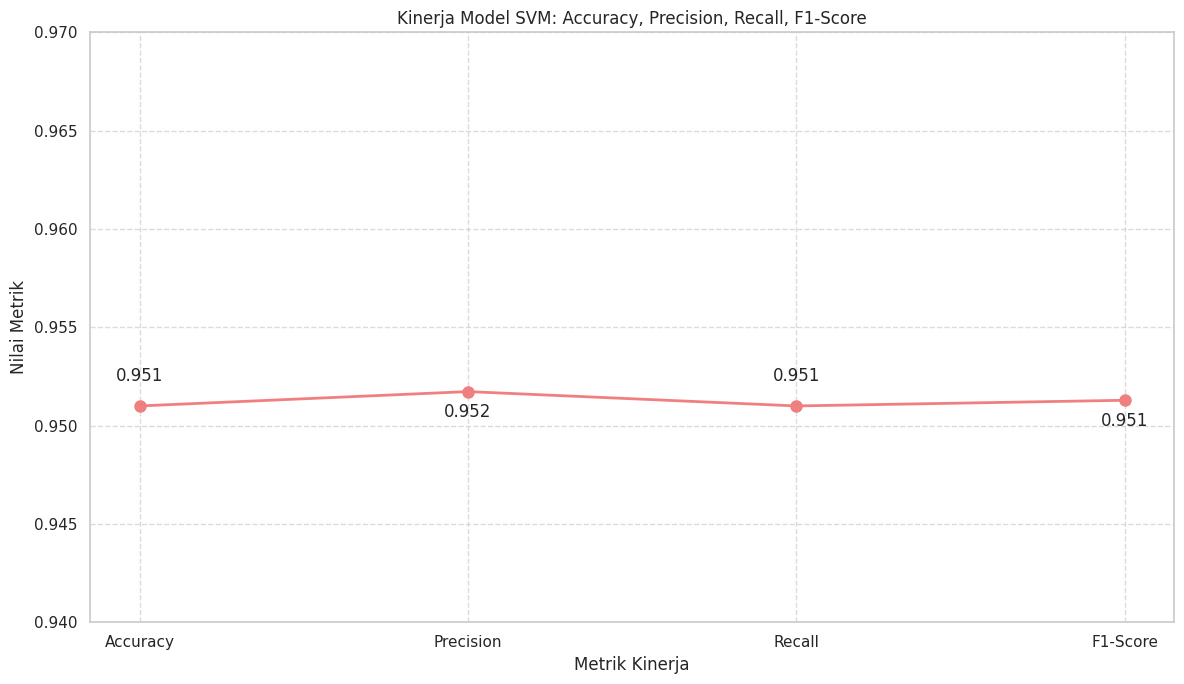

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics data for SVM model
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values_svm = [
    accuracy_svm,
    precision_svm,
    recall_svm,
    f1_svm
]

plt.figure(figsize=(12, 7)) # Increase figure size for better readability

# Plot the line chart
plt.plot(metric_names, metric_values_svm, marker='o', linestyle='-', color='lightcoral', linewidth=2, markersize=8)

# Add value labels for each point with slight vertical offsets to prevent overlap
offsets = [15, -15, 15, -15] # Alternate offsets for better readability
for i, txt in enumerate(metric_values_svm):
    plt.annotate(f'{txt:.3f}', (metric_names[i], metric_values_svm[i]),
                 textcoords="offset points", xytext=(0, offsets[i]), # Apply alternating offset
                 ha='center', va='center' if offsets[i] < 0 else 'bottom') # Adjust vertical alignment

plt.ylim(0.94, 0.97) # Adjust y-axis limits to zoom in but leave more space for labels
plt.ylabel('Nilai Metrik')
plt.xlabel('Metrik Kinerja')
plt.title('Kinerja Model SVM: Accuracy, Precision, Recall, F1-Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

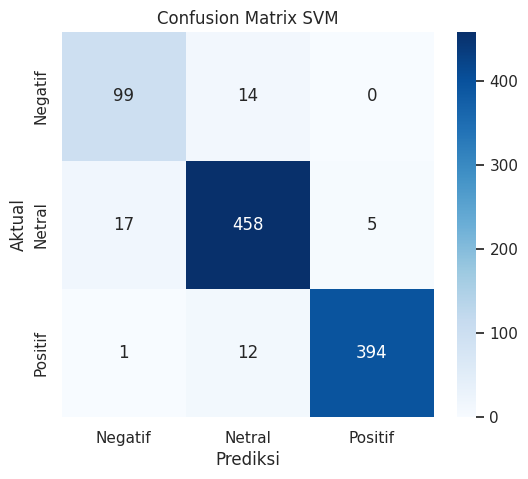

In [24]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()

In [25]:
# ==========================================================
# PERHITUNGAN METRIK
# ==========================================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision_svm = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_svm = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_svm = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

In [ ]:
# ==========================================================
# TABEL HASIL EVALUASI
# ==========================================================

hasil_svm = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (detik)"
    ],
    "Value":[
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm,
        training_time_svm
    ]
})

display(hasil_svm)

,Metric,Value
0,Accuracy,0.976000
1,Precision,0.976125
2,Recall,0.976000
3,F1 Score,0.975691
4,Training Time (detik),0.650471


In [26]:
# ==========================================================
# SIMPAN MODEL
# ==========================================================

import pickle

with open("model_svm.pkl", "wb") as file:
    pickle.dump(model_svm, file)

with open("tfidf.pkl", "wb") as file:
    pickle.dump(tfidf, file)

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [27]:
# ==========================================================
# PREDIKSI REVIEW BARU
# ==========================================================

import re

def prediksi_sentimen_svm(review):

    review = review.lower()

    review = re.sub(r"http\S+", " ", review)
    review = re.sub(r"[^a-zA-Z\s]", " ", review)
    review = re.sub(r"\s+", " ", review).strip()

    review = tfidf.transform([review])

    prediksi = model_svm.predict(review)

    hasil = encoder.inverse_transform(prediksi)[0]

    print("="*60)
    print("Review")
    print(review)
    print("="*60)
    print("Sentimen :", hasil)

TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM

Tabel Perbandingan Algoritma


,Metrik,LSTM,SVM
0,Accuracy,0.956000,0.951000
1,Precision,0.956236,0.951730
2,Recall,0.956000,0.951000
3,F1-Score,0.956095,0.951289


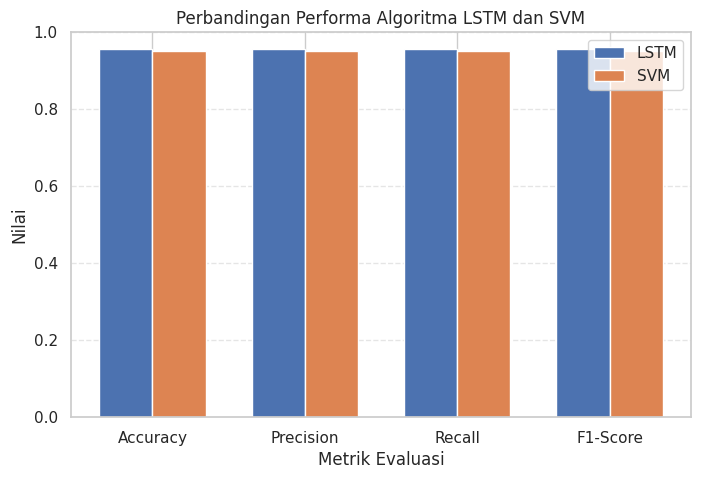

KESIMPULAN PERBANDINGAN
Model Terbaik : LSTM

Accuracy  LSTM : 95.60%
Accuracy  SVM  : 95.10%
Precision LSTM : 95.62%
Precision SVM  : 95.17%
Recall    LSTM : 95.60%
Recall    SVM  : 95.10%
F1-Score  LSTM : 95.61%
F1-Score  SVM  : 95.13%

Kesimpulan :
Berdasarkan hasil evaluasi, algoritma LSTM memiliki
performa yang lebih baik dibandingkan algoritma SVM.
Hal ini ditunjukkan oleh nilai Accuracy, Precision,
Recall, dan F1-Score yang lebih tinggi.
Oleh karena itu, model LSTM dipilih sebagai model
terbaik untuk analisis sentimen ulasan aplikasi
Wondr by BNI.


In [28]:
# ==========================================================
# TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM
# ==========================================================

print("="*60)
print("TAHAP 9 : PERBANDINGAN ALGORITMA LSTM DAN SVM")
print("="*60)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# TABEL PERBANDINGAN
# ==========================================================

perbandingan = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "LSTM": [
        accuracy_lstm,
        precision_lstm,
        recall_lstm,
        f1_lstm
    ],
    "SVM": [
        accuracy_svm,
        precision_svm,
        recall_svm,
        f1_svm
    ]
})

print("\nTabel Perbandingan Algoritma")
display(perbandingan)

# ==========================================================
# GRAFIK PERBANDINGAN
# ==========================================================

plt.figure(figsize=(8,5))

x = np.arange(len(perbandingan))
width = 0.35

plt.bar(
    x - width/2,
    perbandingan["LSTM"],
    width,
    label="LSTM"
)

plt.bar(
    x + width/2,
    perbandingan["SVM"],
    width,
    label="SVM"
)

plt.xticks(x, perbandingan["Metrik"])
plt.ylim(0,1)
plt.ylabel("Nilai")
plt.xlabel("Metrik Evaluasi")
plt.title("Perbandingan Performa Algoritma LSTM dan SVM")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ==========================================================
# MENENTUKAN MODEL TERBAIK
# ==========================================================

print("="*60)
print("KESIMPULAN PERBANDINGAN")
print("="*60)

if accuracy_lstm > accuracy_svm:

    print("Model Terbaik : LSTM\n")

    print(f"Accuracy  LSTM : {accuracy_lstm*100:.2f}%")
    print(f"Accuracy  SVM  : {accuracy_svm*100:.2f}%")

    print(f"Precision LSTM : {precision_lstm*100:.2f}%")
    print(f"Precision SVM  : {precision_svm*100:.2f}%")

    print(f"Recall    LSTM : {recall_lstm*100:.2f}%")
    print(f"Recall    SVM  : {recall_svm*100:.2f}%")

    print(f"F1-Score  LSTM : {f1_lstm*100:.2f}%")
    print(f"F1-Score  SVM  : {f1_svm*100:.2f}%")

    print("\nKesimpulan :")
    print("Berdasarkan hasil evaluasi, algoritma LSTM memiliki")
    print("performa yang lebih baik dibandingkan algoritma SVM.")
    print("Hal ini ditunjukkan oleh nilai Accuracy, Precision,")
    print("Recall, dan F1-Score yang lebih tinggi.")
    print("Oleh karena itu, model LSTM dipilih sebagai model")
    print("terbaik untuk analisis sentimen ulasan aplikasi")
    print("Wondr by BNI.")

else:

    print("Model Terbaik : SVM\n")

    print(f"Accuracy  SVM  : {accuracy_svm*100:.2f}%")
    print(f"Accuracy  LSTM : {accuracy_lstm*100:.2f}%")

    print(f"Precision SVM  : {precision_svm*100:.2f}%")
    print(f"Precision LSTM : {precision_lstm*100:.2f}%")

    print(f"Recall    SVM  : {recall_svm*100:.2f}%")
    print(f"Recall    LSTM : {recall_lstm*100:.2f}%")

    print(f"F1-Score  SVM  : {f1_svm*100:.2f}%")
    print(f"F1-Score  LSTM : {f1_lstm*100:.2f}%")

    print("\nKesimpulan :")
    print("Berdasarkan hasil evaluasi, algoritma SVM memiliki")
    print("performa yang lebih baik dibandingkan algoritma LSTM.")
    print("Oleh karena itu, model SVM dipilih sebagai model")
    print("terbaik untuk analisis sentimen ulasan aplikasi")
    print("Wondr by BNI.")

print("="*60)

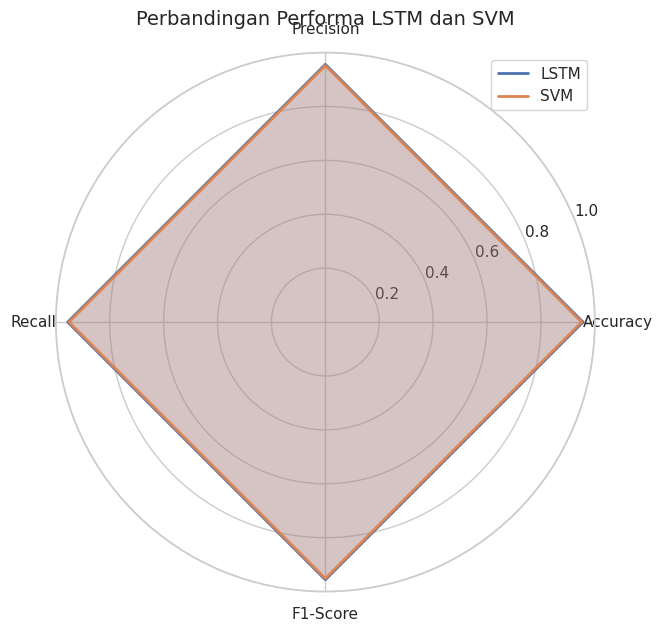

In [29]:
# ==========================================================
# GRAFIK RADAR PERBANDINGAN LSTM DAN SVM
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Data
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

lstm = [accuracy_lstm, precision_lstm, recall_lstm, f1_lstm]
svm  = [accuracy_svm, precision_svm, recall_svm, f1_svm]

# Tutup lingkaran
lstm += lstm[:1]
svm += svm[:1]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

ax.plot(angles, lstm, linewidth=2, label='LSTM')
ax.fill(angles, lstm, alpha=0.25)

ax.plot(angles, svm, linewidth=2, label='SVM')
ax.fill(angles, svm, alpha=0.25)

# Label
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylim(0, 1)
ax.set_title("Perbandingan Performa LSTM dan SVM", fontsize=14, pad=20)

ax.grid(True)
ax.legend(loc='upper right')

plt.show()

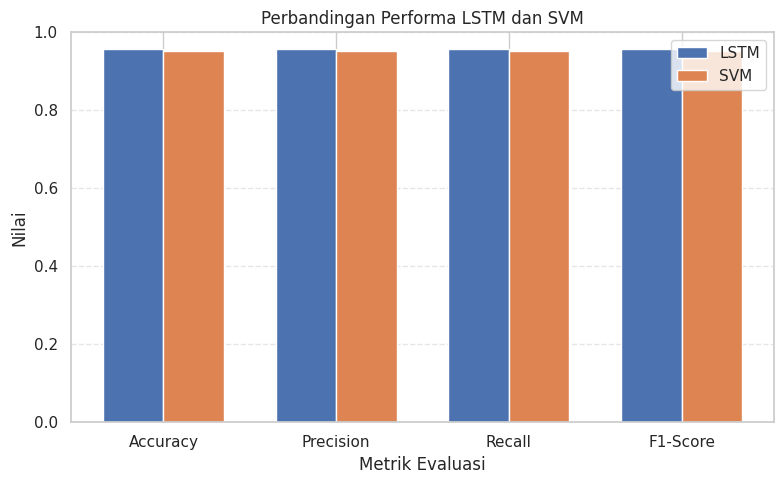

In [32]:
# ==========================================================
# GRAFIK PERBANDINGAN LSTM DAN SVM
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

metrik = ["Accuracy", "Precision", "Recall", "F1-Score"]

lstm = [accuracy_lstm, precision_lstm, recall_lstm, f1_lstm]
svm = [accuracy_svm, precision_svm, recall_svm, f1_svm]

x = np.arange(len(metrik))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, lstm, width, label='LSTM')
plt.bar(x + width/2, svm, width, label='SVM')

plt.xticks(x, metrik)
plt.ylabel("Nilai")
plt.xlabel("Metrik Evaluasi")
plt.title("Perbandingan Performa LSTM dan SVM")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
from google.colab import files

files.download("model_svm.pkl")
files.download("tfidf.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>